# Notebook 04: Inference and Embedding Extraction

We extract **512-dimensional embeddings** from the pretrained transaction foundation model for each transaction using **last-token pooling**, the hidden state at the last non-padding position, which summarizes the full input via causal attention. Tokenization is GPU-accelerated via **cuDF**, delivered by Ray Data with `batch_format="cudf"`.

| Split | Samples | Fraud Rate | Notes |
|-------|---------|------------|-------|
| **Train** | ~1M (balanced) | ~2.5% | Balanced sample for downstream XGBoost |
| **Val** | 100K (stratified) | ~0.1% | Same evaluation subset from notebook 01 |
| **Test** | 100K (stratified) | ~0.1% | Same evaluation subset from notebook 01 |

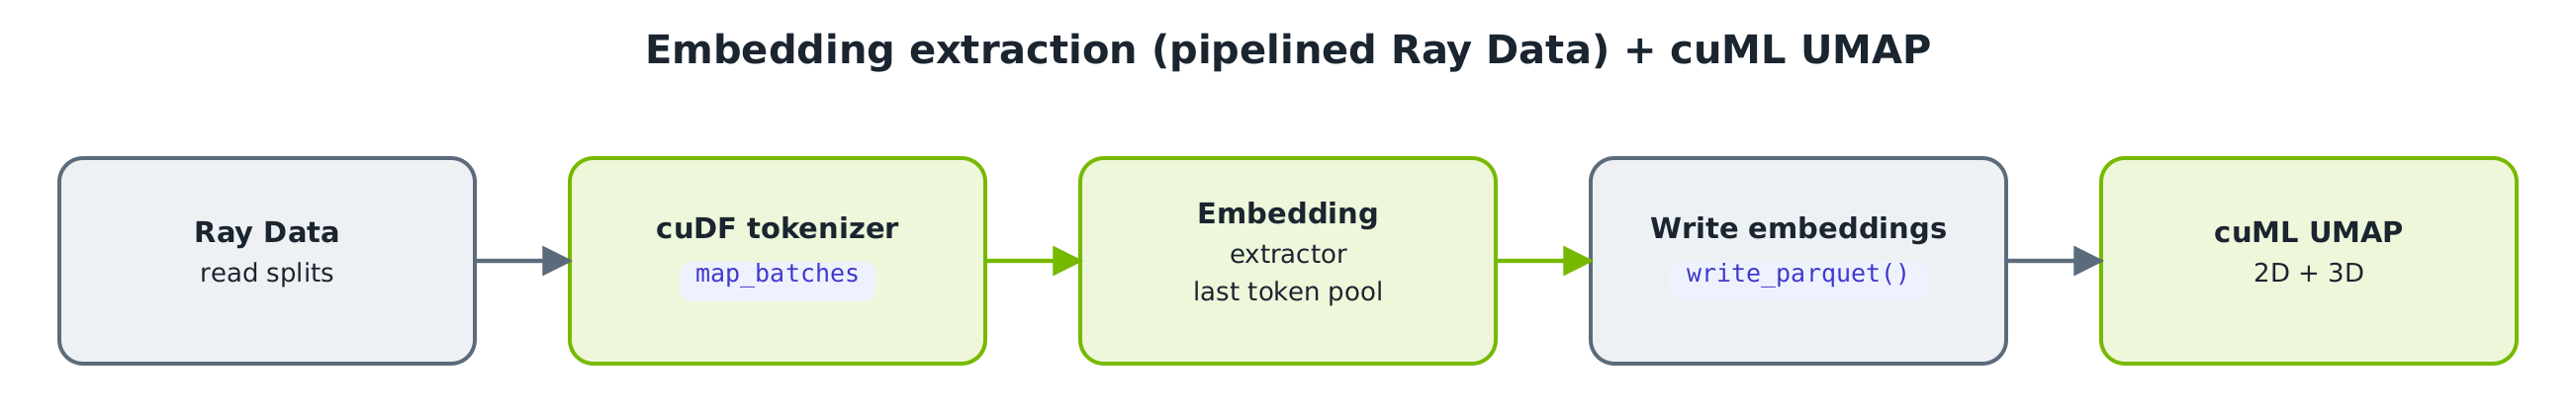

## `Step 0`: Setup

In [1]:
import json
from pathlib import Path

import ray, numpy as np
from src import ray_common as C

if not ray.is_initialized():
    ray.init(address="auto", runtime_env=C.JOB_RUNTIME_ENV)

MODEL_DIR = str(C.MODEL_DIR / "decoder-foundation-model")
assert (Path(MODEL_DIR) / "config.json").exists(), "Run NB03 first to produce the checkpoint."
print(f"GPUs: {ray.cluster_resources().get('GPU', 0):.0f}")
print(f"Model: {MODEL_DIR}")

2026-06-10 18:50:30,065	INFO worker.py:1814 -- Connecting to existing Ray cluster at address: 10.0.128.242:6379...
2026-06-10 18:50:30,115	INFO worker.py:2003 -- Connected to Ray cluster. View the dashboard at https://session-qpwcx5l3g8cwbw1p61s98gvrp4.i.anyscaleuserdata.com 
2026-06-10 18:50:30,129	INFO packaging.py:463 -- Pushing file package 'gcs://_ray_pkg_252a30479169a11d390635e617c2397641b9ccf4.zip' (2.15MiB) to Ray cluster...
2026-06-10 18:50:30,137	INFO packaging.py:476 -- Successfully pushed file package 'gcs://_ray_pkg_252a30479169a11d390635e617c2397641b9ccf4.zip'.


GPUs: 2
Model: /mnt/cluster_storage/tfm_ray/models/decoder-foundation-model


/home/ray/anaconda3/lib/python3.12/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


## `Step 1`: Extract Embeddings (cuDF-Accelerated)

GPU-accelerated tokenization via cuDF + HuggingFace model inference with last-token pooling. 

- The training split uses a balanced subsample (~1M rows, ~2.5% fraud) to match the downstream XGBoost training setup in notebook 05. 
- Val and test use the 100k stratified subsets saved in notebook 01 (`val_eval.parquet` and `test_eval.parquet`).

In [2]:
import shutil, time
from src.ray_tokenize import GPUTokenizer
from src.ray_embed import EmbeddingExtractor

SPLIT_SRC = {"train": "train_balanced", "val": "val_eval", "test": "test_eval"}

# Raw features carried through the pipeline so the embeddings table is row-aligned
# with raw features (NB05 "combined" model). 'Hour' is derived inside preprocess.
FEATURE_COLS = ['User', 'Card', 'Year', 'Month', 'Day', 'Hour', 'Amount',
                'Use Chip', 'Merchant Name', 'Merchant City', 'Merchant State',
                'Zip', 'MCC']

for split, src in SPLIT_SRC.items():
    out = C.EMBED_DIR / split
    # Idempotent re-runs: skip extraction if this split's embeddings already exist.
    if out.exists() and any(out.iterdir()):
        back = ray.data.read_parquet(str(out))
        print(f"[{split}] already extracted: {back.count():,} embeddings at {out}")
        continue

    t0 = time.time()
    ds = ray.data.read_parquet(str(C.SPLIT_DIR / src))

    toks = ds.map_batches(
        GPUTokenizer,
        fn_constructor_kwargs={"merchant_hash_size": C.MERCHANT_HASH_SIZE,
                               "carry_cols": FEATURE_COLS},
        batch_size=16384, compute=ray.data.ActorPoolStrategy(size=1), num_gpus=1,
        batch_format="cudf", runtime_env=C.GPU_RUNTIME_ENV,
    )
    emb = toks.map_batches(
        EmbeddingExtractor, fn_constructor_kwargs={"model_dir": MODEL_DIR},
        batch_size=4096, compute=ray.data.ActorPoolStrategy(size=1), num_gpus=1,
        batch_format="numpy", runtime_env=C.GPU_RUNTIME_ENV,
    )
    shutil.rmtree(out, ignore_errors=True)
    emb.write_parquet(str(out))

    back = ray.data.read_parquet(str(out))
    n = back.count()
    n_fraud = back.filter(expr="label == 1").count()
    print(f"[{split}] {n:,} embeddings ({n_fraud:,} fraud) -> {out}  ({time.time()-t0:.0f}s)")

# small metadata file for NB05
meta = {"embedding_dim": C.MODEL_CONFIG["hidden_size"], "pooling": "last_token",
        "splits": list(SPLIT_SRC), "model_dir": MODEL_DIR}
(C.EMBED_DIR / "metadata.json").write_text(json.dumps(meta, indent=2))
print("\nmetadata:", meta)

2026-06-10 18:50:31,636	INFO logging.py:416 -- Registered dataset logger for dataset dataset_94_0
2026-06-10 18:50:31,656	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_94_0. Full logs are in /tmp/ray/session_2026-06-10_15-54-26_041190_3241/logs/ray-data
2026-06-10 18:50:31,657	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_94_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ListFiles] -> TaskPoolMapOperator[MapBatches(count_rows)]
2026-06-10 18:50:31,660	WARNING resource_manager.py:169 -- ⚠️  Ray's object store is configured to use only 28.1% of available memory (179.8GiB out of 640.0GiB total). For optimal Ray Data performance, we recommend setting the object store to at least 50% of available memory. You can do this by setting the 'object_store_memory' parameter when calling ray.init() or by setting the RAY_DEFAULT_OBJECT_STORE_MEMORY_PROPORTION environment variable.
2026-06-10 18:50:31,662	INFO __init__.py:56 -- Progress will be logged 

[train] already extracted: 995,985 embeddings at /mnt/cluster_storage/tfm_ray/embeddings/train
[val] already extracted: 99,395 embeddings at /mnt/cluster_storage/tfm_ray/embeddings/val


2026-06-10 18:50:38,103	INFO streaming_executor.py:294 -- ✔️  Dataset dataset_98_0 execution finished in 0.08 seconds
INFO:openlineage.client.client:OpenLineageClient will use `composite` transport
INFO:openlineage.client.transport.composite:Stopping OpenLineage CompositeTransport emission after the first successful delivery because `continue_on_success=False`. Transport that emitted the event: <HttpTransport(name=first, kind=http, priority=1)>


[test] already extracted: 99,402 embeddings at /mnt/cluster_storage/tfm_ray/embeddings/test

metadata: {'embedding_dim': 512, 'pooling': 'last_token', 'splits': ['train', 'val', 'test'], 'model_dir': '/mnt/cluster_storage/tfm_ray/models/decoder-foundation-model'}


## `Step 2`: Load Embeddings

Load the streamed val+test embedding Parquet back into memory and assemble the matrix `X` (512-d) with fraud labels `y`. 

The Parquet also carries the raw transaction features (row-aligned), which we use both for the NB05 "combined" model and for the feature-colored 3D explorer below.

In [3]:
import pandas as pd

def load_emb(split):
    df = pd.read_parquet(C.EMBED_DIR / split)
    X = np.stack(df["embedding"].to_numpy())
    y = df["label"].to_numpy().astype(int)
    return X, y, df

Xv, yv, dv = load_emb("val"); Xt, yt, dt = load_emb("test")
X = np.concatenate([Xv, Xt]); y = np.concatenate([yv, yt])
raw_all = pd.concat([dv, dt], ignore_index=True)
print(f"Embeddings: {X.shape}  | fraud: {y.sum():,} / {len(y):,} ({y.mean():.3%})")
print(f"Pooling: last_token (matches the original)")

Embeddings: (198797, 512)  | fraud: 163 / 198,797 (0.082%)
Pooling: last_token (matches the original)


## `Step 3`: Visualization with GPU-Accelerated UMAP

We project the 512-d embeddings to 2-D and 3-D with **GPU-accelerated UMAP** (cuML), the *same algorithm and parameters as the original*. On this cluster the
head node has an A10G GPU, so we run cuML UMAP directly here; the projection is a small one-shot analysis step on a 50k subsample.


In [4]:

import os, glob, site
if not os.path.exists(os.path.join(os.environ.get("CUDA_PATH", ""), "include", "cuda_fp16.h")):
    for base in site.getsitepackages():
        hits = glob.glob(os.path.join(base, "nvidia", "*", "include", "cuda_fp16.h"))
        if hits:
            os.environ["CUDA_PATH"] = os.path.dirname(os.path.dirname(hits[0]))
            break

import cupy as cp
from cuml.manifold import UMAP

def umap_gpu(X, n_components):
    Z = UMAP(n_neighbors=15, n_components=n_components, min_dist=0.1,
             metric="euclidean", random_state=42).fit_transform(cp.asarray(X))
    return cp.asnumpy(Z)

# MCC -> industry label (same table as NB01/the original).
MCC_INDUSTRY_RANGES = [
    (0,1499,"Agricultural"),(1500,2999,"Contracted"),(3000,3299,"Airlines"),
    (3300,3499,"Car Rental"),(3500,3999,"Lodging"),(4000,4799,"Transportation"),
    (4800,4999,"Utilities"),(5000,5599,"Retail"),(5600,5699,"Clothing"),
    (5700,7299,"Misc Stores"),(7300,7999,"Business Services"),
    (8000,8999,"Professional"),(9000,9999,"Government"),
]
def industry_of(mcc):
    try: mcc = int(mcc)
    except Exception: return "Unknown"
    for lo, hi, name in MCC_INDUSTRY_RANGES:
        if lo <= mcc <= hi: return name
    return "Other"

_AMT_BINS  = [0,10,50,100,500,1000,5000,float("inf")]
_AMT_LABEL = ["$0-10","$10-50","$50-100","$100-500","$500-1k","$1k-5k","$5k+"]
def amount_bucket(a):
    try: a = float(str(a).replace("$","").replace(",",""))
    except Exception: return "Unknown"
    for i in range(len(_AMT_BINS)-1):
        if _AMT_BINS[i] <= a < _AMT_BINS[i+1]: return _AMT_LABEL[i]
    return _AMT_LABEL[-1]

# Subsample for the projection (matches the original's viz_size).
viz_size = min(50_000, len(X))
rng = np.random.default_rng(42)
idx = rng.choice(len(X), viz_size, replace=False)
sub_X, sub_y, sub_raw = X[idx], y[idx], raw_all.iloc[idx].reset_index(drop=True)

print(f"Running GPU-accelerated cuML UMAP (2D + 3D) on {viz_size:,} samples...")
sub_X = np.ascontiguousarray(sub_X, dtype=np.float32)
umap_2d = umap_gpu(sub_X, 2)
umap_3d = umap_gpu(sub_X, 3)
print(f"UMAP complete: 2D {umap_2d.shape}, 3D {umap_3d.shape}")

# Feature-annotated frame for the colored explorer.
viz_df = pd.DataFrame({
    "umap_1": umap_2d[:,0], "umap_2": umap_2d[:,1],
    "umap3_x": umap_3d[:,0], "umap3_y": umap_3d[:,1], "umap3_z": umap_3d[:,2],
    "industry": [industry_of(m) for m in sub_raw["MCC"]],
    "mcc": sub_raw["MCC"].astype(str).values,
    "state": sub_raw["Merchant State"].fillna("XX").replace("", "XX").values,
    "chip_type": sub_raw["Use Chip"].fillna("Unknown").values,
    "amount_bucket": [amount_bucket(a) for a in sub_raw["Amount"]],
    "zip3": sub_raw["Zip"].astype(str).str[:3].values,
    "city": sub_raw["Merchant City"].fillna("Unknown").values,
    "fraud": ["Fraud" if v == 1 else "Normal" for v in sub_y],
})
AXIS_RANGE = 12

Running GPU-accelerated cuML UMAP (2D + 3D) on 50,000 samples...
[2026-06-10 18:50:43.535] [CUML] [info] build_algo set to brute_force_knn because random_state is given
[2026-06-10 18:50:45.097] [CUML] [info] build_algo set to brute_force_knn because random_state is given
UMAP complete: 2D (50000, 2), 3D (50000, 3)


### 2D UMAP — Fraud vs Normal

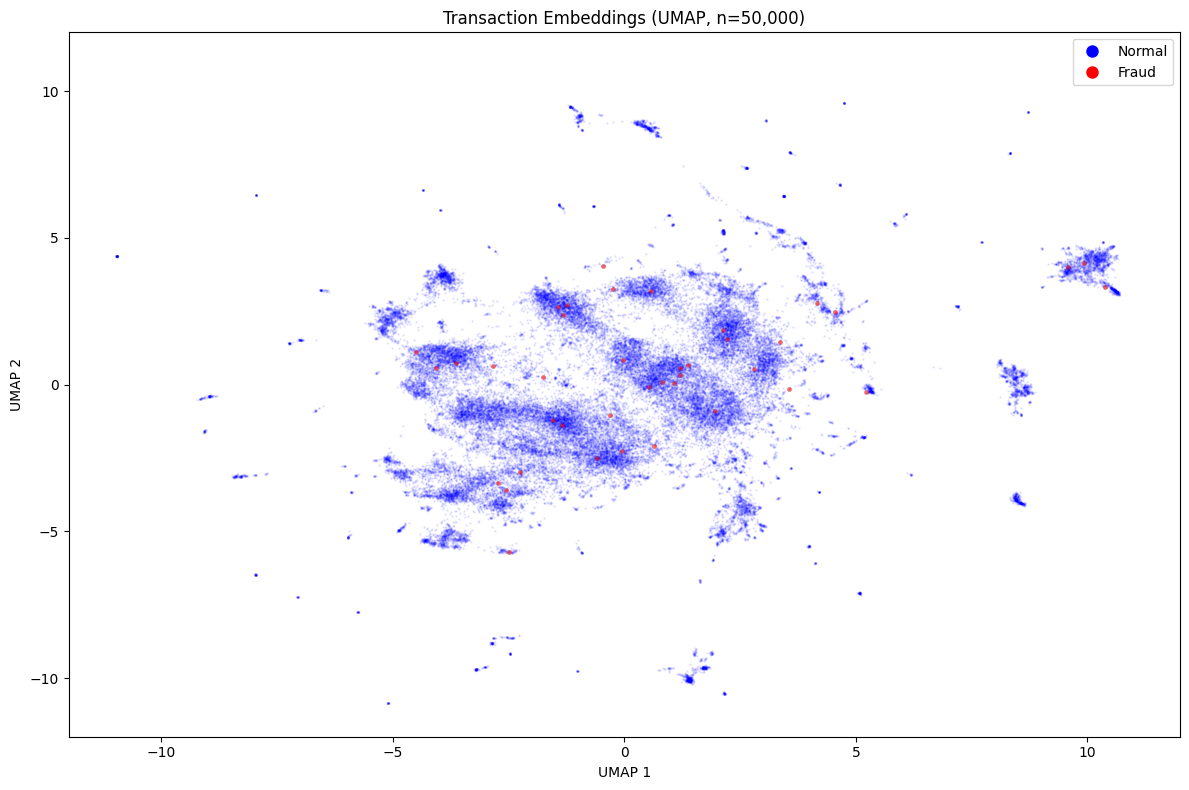

Saved /mnt/cluster_storage/tfm_ray/embeddings/umap_visualization.png


In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.figure(figsize=(12, 8))
m_norm, m_fraud = (sub_y == 0), (sub_y == 1)
plt.scatter(umap_2d[m_norm,0], umap_2d[m_norm,1], c="blue", alpha=0.08, s=0.7, label="Normal")
plt.scatter(umap_2d[m_fraud,0], umap_2d[m_fraud,1], c="red", alpha=0.6, s=10,
            edgecolor="k", linewidth=0.1, label="Fraud")
plt.legend(handles=[
    Line2D([0],[0], marker="o", color="w", markerfacecolor="blue", markersize=10, label="Normal"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="red", markersize=10, label="Fraud"),
], loc="upper right")
plt.title(f"Transaction Embeddings (UMAP, n={viz_size:,})")
plt.xlabel("UMAP 1"); plt.ylabel("UMAP 2")
plt.xlim(-AXIS_RANGE, AXIS_RANGE); plt.ylim(-AXIS_RANGE, AXIS_RANGE)
plt.tight_layout(); plt.savefig(C.EMBED_DIR / "umap_visualization.png", dpi=150)
plt.show()
print(f"Saved {C.EMBED_DIR / 'umap_visualization.png'}")

### 3D Interactive UMAP with Feature Toggle

A single Plotly `Scatter3d` whose marker colors swap via a dropdown, explore the embedding manifold colored by fraud, industry, state, chip type, amount bucket or
ZIP3 (identical to the original's explorer). Saved as a standalone HTML.

In [6]:
%pip install -q plotly
import matplotlib
import plotly.graph_objects as go
from IPython.display import IFrame, HTML, display as ipy_display

def _tab20_hex(n):
    cmap = matplotlib.colormaps["tab20"].resampled(max(n, 2))
    return ["#{:02x}{:02x}{:02x}".format(int(r*255),int(g*255),int(b*255))
            for r,g,b,_ in [cmap(i) for i in range(n)]]
GRAY = "#d3d3d3"

toggle_specs = [
    ("Fraud","fraud",None), ("Industry","industry",None), ("Industry (top 8)","industry",8),
    ("State","state",None), ("State (top 4)","state",4), ("Chip Type","chip_type",None),
    ("Amount Bucket","amount_bucket",None), ("ZIP3 (top 10)","zip3",10),
]
hover = [f"Industry: {r.industry}<br>MCC: {r.mcc}<br>State: {r.state}<br>City: {r.city}<br>"
         f"Chip: {r.chip_type}<br>Amount: {r.amount_bucket}<br>Fraud: {r.fraud}"
         for r in viz_df.itertuples()]

color_arrays = []
for _label, col, top_n in toggle_specs:
    vals = viz_df[col].values
    if top_n is not None:
        keys = viz_df[col].value_counts().head(top_n).index.tolist()
    else:
        keys = sorted(viz_df[col].dropna().unique())
    cmap = dict(zip(keys, _tab20_hex(len(keys))))
    color_arrays.append([cmap.get(v, GRAY) for v in vals])

fig3d = go.Figure(go.Scatter3d(
    x=viz_df["umap3_x"], y=viz_df["umap3_y"], z=viz_df["umap3_z"], mode="markers",
    marker=dict(size=1.5, color=color_arrays[0], opacity=0.5), text=hover,
    hoverinfo="text", name=toggle_specs[0][0],
))
buttons = [dict(label=lab, method="update",
                args=[{"marker.color":[color_arrays[i]], "name":[lab]},
                      {"title.text": f"3D Embedding Explorer — {lab}"}])
           for i,(lab,_c,_t) in enumerate(toggle_specs)]
fig3d.update_layout(
    title=dict(text=f"3D Embedding Explorer — Fraud (n={len(viz_df):,})", x=0.5, xanchor="center"),
    scene=dict(xaxis=dict(title="UMAP 1", range=[-AXIS_RANGE,AXIS_RANGE]),
               yaxis=dict(title="UMAP 2", range=[-AXIS_RANGE,AXIS_RANGE]),
               zaxis=dict(title="UMAP 3", range=[-AXIS_RANGE,AXIS_RANGE]),
               camera=dict(eye=dict(x=1.5,y=1.5,z=1.2))),
    updatemenus=[dict(type="dropdown", direction="down", x=0.01, xanchor="left",
                      y=0.97, yanchor="top", buttons=buttons, bgcolor="white", bordercolor="gray")],
    width=950, height=750, margin=dict(l=0,r=0,b=0,t=80), showlegend=False,
)
html_path = C.EMBED_DIR / "umap_3d_interactive.html"
fig3d.write_html(str(html_path), include_plotlyjs=True)
print(f"Saved {html_path}")
try:
    ipy_display(IFrame(src=str(html_path.relative_to(Path.cwd())), width="100%", height="780px"))
except Exception:
    ipy_display(HTML(f'<b>Interactive 3D plot saved.</b> Open: <a href="{html_path}">{html_path.name}</a>'))

Note: you may need to restart the kernel to use updated packages.
Saved /mnt/cluster_storage/tfm_ray/embeddings/umap_3d_interactive.html


## Summary

Embedding extraction is now a **pipelined Ray Data** job: cuDF tokenization and GPU decoder inference run concurrently across A10G workers and stream 512-d
embeddings to **Parquet** (no monolithic `.npy`, no single-GPU memory ceiling). The downstream analysis mirrors the original: load embeddings, then **UMAP** 2-D (fraud vs normal) and an interactive **3-D explorer** with a feature-color toggle.


Continue to **`05_xgboost_fraud_detection_ray.ipynb`**.